# Volume Profile + CVD Absorption Strategy — v9 (Value Boundary, Extended)

真實 BTCUSDT 數據 · 5 日 Composite Profile + 前一日 VAL/VAH/POC · CVD 吸收力竭檢測 + 動態 2% 風險管理

**v9 Rules:**
1. No raw POC entry — only trade value boundaries (VAL/VAH)
2. Long: VAL rejection or VAH reclaim. Short: VAH rejection or VAL breakdown.
3. POC = target (inside value), resistance (below), support (above).
4. CVD regime filter: session-level CVD direction gates entries.
5. Cooldown after stop-out + max 2 trades per (level, direction) per day.
6. Breakout trades (VAH reclaim / VAL breakdown): multi-target exits with trailing runner.

**Extended test window**: Mar 11–22 (10 trading days).

In [1]:
import io, zipfile, warnings, time, math
from collections import defaultdict
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dataclasses import dataclass, field
from nautilus_trader.test_kit.providers import TestInstrumentProvider

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(14,5)})
INSTRUMENT = TestInstrumentProvider.btcusdt_perp_binance()
TICK_SIZE, VA_PCT = 0.1, 0.70

PROFILE_DAYS = ['2024-03-04','2024-03-05','2024-03-06','2024-03-07','2024-03-08']
TEST_DAYS    = ['2024-03-11','2024-03-12','2024-03-13','2024-03-14','2024-03-15',
                '2024-03-18','2024-03-19','2024-03-20','2024-03-21','2024-03-22']

ACCOUNT_BALANCE  = 100_000.0
RISK_PER_TRADE   = 0.02
STOP_LOSS_PCT    = 0.02
TOUCH_BUFFER     = 0.002
MIN_IMBALANCE    = 1.2
MIN_DELTA_RATIO  = 0.02
BREAKEVEN_PCT    = 0.005
CVD_LOOKBACK     = 5

BREAKOUT_CONFIRM_BARS  = 3
BREAKOUT_FAILURE_BARS  = 3
ATR_PERIOD             = 14
COOLDOWN_BARS          = 5
MAX_TRADES_PER_LEVEL   = 2
TRAIL_MULTIPLE         = 0.5
SESSION_CVD_LOOKBACK   = 30

print(f'Profile: {PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]}  Test: {TEST_DAYS[0]}..{TEST_DAYS[-1]} ({len(TEST_DAYS)} days)')
print(f'Risk: {RISK_PER_TRADE*100:.0f}% | Breakout confirm: {BREAKOUT_CONFIRM_BARS}b | ATR: {ATR_PERIOD}b')
print(f'Cooldown: {COOLDOWN_BARS}b | Max/level: {MAX_TRADES_PER_LEVEL} | CVD session lookback: {SESSION_CVD_LOOKBACK}b')

C:\Users\cyt\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Profile: 2024-03-04..2024-03-08  Test: 2024-03-11..2024-03-22 (10 days)
Risk: 2% | Breakout confirm: 3b | ATR: 14b
Cooldown: 5b | Max/level: 2 | CVD session lookback: 30b


In [2]:
# === Download ===
CACHE = {}
def dl(data_type, date):
    k=(data_type,date)
    if k in CACHE: return CACHE[k]
    url=f'https://data.binance.vision/data/futures/um/daily/{data_type}/BTCUSDT/BTCUSDT-{data_type}-{date}.zip'
    r=requests.get(url); r.raise_for_status()
    CACHE[k]=r.content; return r.content

def rd_agg(date):
    z=zipfile.ZipFile(io.BytesIO(dl('aggTrades',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c))

def rd_bk(date, sample=50):
    z=zipfile.ZipFile(io.BytesIO(dl('bookTicker',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c), skiprows=lambda i: i>0 and i%sample!=0)

print('Helper ready.')

Helper ready.


In [3]:
# === Profile Calculator ===
@dataclass
class DayProfile:
    date:str; poc:float; vah:float; val:float
    total_volume:float; price_levels:dict=field(repr=False)

def calc_profile(df):
    df=df.copy(); df['b']=np.round(df['price']/TICK_SIZE)*TICK_SIZE
    vp=df.groupby('b')['quantity'].sum(); tv=vp.sum(); poc=vp.idxmax()
    levels=vp.sort_index(); idx=list(levels.index); pp=idx.index(poc)
    cv=levels.iloc[pp]; inc={poc}; t=tv*VA_PCT; l,r=pp-1,pp+1
    while cv<t and (l>=0 or r<len(idx)):
        vl=levels.iloc[l] if l>=0 else 0; vr=levels.iloc[r] if r<len(idx) else 0
        if vl>=vr and l>=0: inc.add(idx[l]); cv+=vl; l-=1
        elif r<len(idx): inc.add(idx[r]); cv+=vr; r+=1
        else: break
    ds=pd.Timestamp(df['transact_time'].iloc[0],unit='ms').strftime('%Y-%m-%d')
    return DayProfile(date=ds,poc=poc,vah=max(inc),val=min(inc),total_volume=tv,price_levels=vp.to_dict())

t0=time.time()
comp_vp={}; comp_tv=0; day_profs={}
for d in PROFILE_DAYS:
    print(f'Profile {d}...',end=' ')
    df=rd_agg(d); p=calc_profile(df)
    day_profs[d]=p; comp_tv+=p.total_volume
    for px,v in p.price_levels.items(): comp_vp[px]=comp_vp.get(px,0)+v
    print(f'{len(df):,}t VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}'); del df

cp=max(comp_vp,key=comp_vp.get); sp=sorted(comp_vp.keys()); pp=sp.index(cp)
cv=comp_vp[cp]; inc={cp}; l,r=pp-1,pp+1
while cv<comp_tv*VA_PCT and (l>=0 or r<len(sp)):
    vl=comp_vp[sp[l]] if l>=0 else 0; vr=comp_vp[sp[r]] if r<len(sp) else 0
    if vl>=vr and l>=0: inc.add(sp[l]); cv+=vl; l-=1
    elif r<len(sp): inc.add(sp[r]); cv+=vr; r+=1
    else: break
COMP_VAL, COMP_VAH, COMP_POC = min(inc), max(inc), cp
print(f'\nComposite: VAL={COMP_VAL:.0f} POC={COMP_POC:.0f} VAH={COMP_VAH:.0f} ({time.time()-t0:.0f}s)')

Profile 2024-03-04... 

3,043,615t VAL=64584 POC=65000 VAH=67800
Profile 2024-03-05... 

5,270,260t VAL=61610 POC=63300 VAH=67300
Profile 2024-03-06... 

3,092,594t VAL=65856 POC=66000 VAH=67416
Profile 2024-03-07... 

1,794,188t VAL=66675 POC=67000 VAH=67866
Profile 2024-03-08... 

2,606,144t VAL=67098 POC=68000 VAH=68959

Composite: VAL=65196 POC=67000 VAH=68797 (27s)


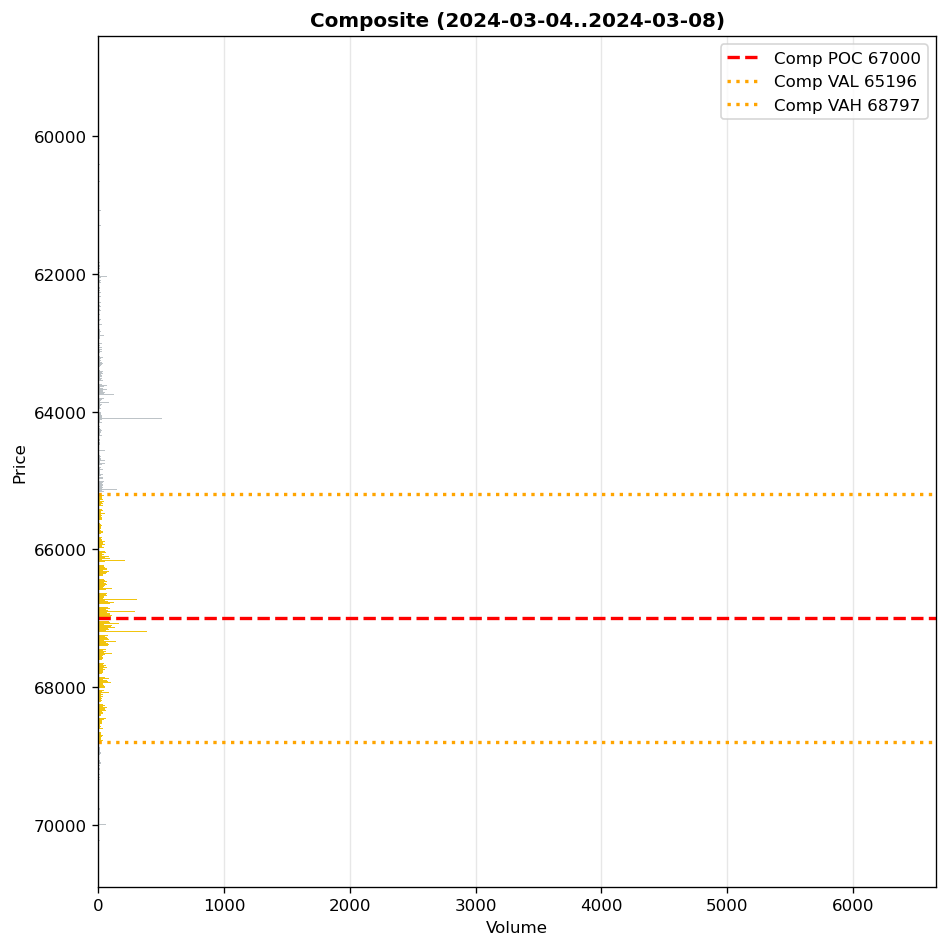

Composite: VAL=65196  POC=67000  VAH=68797
Day profiles:
  2024-03-04: VAL=64584 POC=65000 VAH=67800
  2024-03-05: VAL=61610 POC=63300 VAH=67300
  2024-03-06: VAL=65856 POC=66000 VAH=67416
  2024-03-07: VAL=66675 POC=67000 VAH=67866
  2024-03-08: VAL=67098 POC=68000 VAH=68959


In [4]:
# === Profile Chart ===
fig,ax=plt.subplots(figsize=(8,8))
sp=sorted(comp_vp.keys()); vl=[comp_vp[px] for px in sp]
cl=['#e74c3c' if px==COMP_POC else '#f1c40f' if COMP_VAL<=px<=COMP_VAH else '#bdc3c7' for px in sp]
ax.barh(sp,vl,height=TICK_SIZE*0.8,color=cl,ec='none')
ax.axhline(COMP_POC,color='red',lw=2,ls='--',label=f'Comp POC {COMP_POC:.0f}')
ax.axhline(COMP_VAL,color='orange',lw=2,ls=':',label=f'Comp VAL {COMP_VAL:.0f}')
ax.axhline(COMP_VAH,color='orange',lw=2,ls=':',label=f'Comp VAH {COMP_VAH:.0f}')
ax.invert_yaxis(); ax.legend(); ax.set_xlabel('Volume'); ax.set_ylabel('Price')
ax.set_title(f'Composite ({PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]})',fontweight='bold'); ax.grid(alpha=0.3,axis='x')
plt.tight_layout(); plt.show()

print(f'Composite: VAL={COMP_VAL:.0f}  POC={COMP_POC:.0f}  VAH={COMP_VAH:.0f}')
print(f'Day profiles:')
for d in PROFILE_DAYS:
    p=day_profs[d]; print(f'  {d}: VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}')

In [5]:
# === Strategy v9: Value Boundary + CVD Regime + Multi-Target ===
class Strategy:
    def __init__(self, prior_val, prior_vah, prior_poc):
        self.prior_val=prior_val; self.prior_vah=prior_vah; self.prior_poc=prior_poc
        
        # Bar state
        self.bar_open=None; self.bar_close_px=None; self.bar_high=None; self.bar_low=None
        self.bar_vol=self.bar_buy=self.bar_sell=0; self.bar_count=0
        self.bar_lows=[]; self.bar_highs=[]
        
        # CVD tracking
        self.cvd=0.0; self.cvd_history=[]; self.bar_deltas=[]
        
        # Quotes
        self.quotes_buf=[]
        
        # ATR
        self.bar_ranges=[]; self.atr=0.0
        
        # Trade log
        self.trades_log=[]
        
        # Active trade state
        self.trade=None  # dict or None
        
        # Breakout monitoring
        self.breakout_setup=None   # 'VAH_LONG', 'VAL_SHORT'
        self.breakout_bars=0
        
        # Cooldown
        self.last_stop_bar=0; self.side_when_stopped=None
        
        # Trade count per (level, direction)
        self.trade_counts=defaultdict(int)

    def on_quote(self,bp,ap,bq,aq):
        self.quotes_buf.append((bp,ap,bq,aq))
        if len(self.quotes_buf)>100: self.quotes_buf.pop(0)

    def on_trade(self,price,qty,is_buyer_maker,ts):
        if self.bar_open is None:
            self.bar_open=self.bar_high=self.bar_low=price; self.bar_ts=ts
        self.bar_high=max(self.bar_high,price)
        self.bar_low=min(self.bar_low,price)
        self.bar_close_px=price
        self.bar_vol+=qty
        if not is_buyer_maker: self.bar_buy+=qty
        else: self.bar_sell+=qty
        self.bar_count+=1

    def on_bar_close(self,ts=None):
        if self.bar_open is None: return
        close=self.bar_close_px
        delta=self.bar_buy-self.bar_sell
        total=self.bar_buy+self.bar_sell
        dr=delta/total if total>0 else 0
        
        # CVD update
        self.cvd+=delta
        self.cvd_history.append(self.cvd)
        self.bar_deltas.append(delta)
        self.bar_lows.append(self.bar_low)
        self.bar_highs.append(self.bar_high)
        if len(self.bar_lows)>max(CVD_LOOKBACK,SESSION_CVD_LOOKBACK)*2:
            self.bar_lows.pop(0); self.bar_highs.pop(0)
            self.cvd_history.pop(0); self.bar_deltas.pop(0)
        
        # ATR update
        if self.bar_high and self.bar_low:
            self.bar_ranges.append(self.bar_high-self.bar_low)
            if len(self.bar_ranges)>ATR_PERIOD: self.bar_ranges.pop(0)
            if len(self.bar_ranges)>=ATR_PERIOD:
                self.atr=sum(self.bar_ranges)/len(self.bar_ranges)
        
        # Breakout monitoring
        self._update_breakout_monitoring(close)
        
        # Entry or exit
        if self.trade is None:
            self._try_entry(close,dr,total,ts)
        else:
            self._check_exit(close,ts)
        
        # Reset bar
        self.bar_open=None; self.bar_close_px=None; self.bar_high=None; self.bar_low=None
        self.bar_vol=self.bar_buy=self.bar_sell=0; self.bar_count=0

    # --- CVD helpers ---
    def _imbalance(self,favor_buy=True):
        if len(self.quotes_buf)<3: return 0.0
        rs=[]
        for _,_,bq,aq in self.quotes_buf[-10:]:
            if bq>0 and aq>0: rs.append(bq/aq if favor_buy else aq/bq)
        return float(np.mean(rs)) if rs else 0.0

    def _cvd_divergence(self,check_bullish=True):
        if len(self.bar_lows)<CVD_LOOKBACK+1: return False
        recent_lows=self.bar_lows[-(CVD_LOOKBACK+1):]
        recent_cvd=self.cvd_history[-(CVD_LOOKBACK+1):]
        if check_bullish:
            if self.bar_low<min(recent_lows[:-1]):
                if self.cvd>=min(recent_cvd[:-1]):
                    return True
        else:
            if self.bar_high>max(self.bar_highs[-(CVD_LOOKBACK+1):-1]):
                if self.cvd<=max(recent_cvd[:-1]):
                    return True
        return False

    def _cvd_regime_bullish(self):
        if len(self.cvd_history)<SESSION_CVD_LOOKBACK: return False
        return self.cvd_history[-1]>self.cvd_history[-SESSION_CVD_LOOKBACK]

    def _cvd_regime_bearish(self):
        if len(self.cvd_history)<SESSION_CVD_LOOKBACK: return False
        return self.cvd_history[-1]<self.cvd_history[-SESSION_CVD_LOOKBACK]

    # --- Cooldown & trade count ---
    def _cooldown_active(self,side):
        if self.side_when_stopped is None or self.last_stop_bar==0: return False
        if self.side_when_stopped!=side: return False
        return len(self.cvd_history)-self.last_stop_bar<COOLDOWN_BARS

    def _can_trade_level(self,level,side):
        return self.trade_counts[f'{level}_{side.lower()}']<MAX_TRADES_PER_LEVEL

    # --- Breakout monitoring ---
    def _update_breakout_monitoring(self,price):
        if self.trade is not None:
            self.breakout_setup=None; self.breakout_bars=0; return
        if self.breakout_setup=='VAH_LONG':
            if price>self.prior_vah: self.breakout_bars+=1
            else: self.breakout_setup=None; self.breakout_bars=0
        elif self.breakout_setup=='VAL_SHORT':
            if price<self.prior_val: self.breakout_bars+=1
            else: self.breakout_setup=None; self.breakout_bars=0
        else:
            if price>self.prior_vah: self.breakout_setup='VAH_LONG'; self.breakout_bars=1
            elif price<self.prior_val: self.breakout_setup='VAL_SHORT'; self.breakout_bars=1

    # --- Entry ---
    def _try_entry(self,price,dr,total,ts):
        cvd_bull=self._cvd_regime_bullish()
        cvd_bear=self._cvd_regime_bearish()
        absorption=self._cvd_divergence(True)
        exhaustion=self._cvd_divergence(False)
        buy_imb=self._imbalance(True)>=MIN_IMBALANCE
        sell_imb=self._imbalance(False)>=MIN_IMBALANCE
        buy_delta=dr>MIN_DELTA_RATIO
        sell_delta=dr<-MIN_DELTA_RATIO
        
        near_val=abs(price-self.prior_val)/self.prior_val<=TOUCH_BUFFER
        near_vah=abs(price-self.prior_vah)/self.prior_vah<=TOUCH_BUFFER
        
        cool_long=self._cooldown_active('LONG')
        cool_short=self._cooldown_active('SHORT')
        
        # VAL rejection -> LONG (mean-reversion)
        if (cvd_bull and near_val and absorption and buy_delta and buy_imb
            and not cool_long and self._can_trade_level('VAL','LONG')):
            self._enter(price,ts,'LONG','VAL','val_rejection','mean_reversion')
            return
        
        # VAH rejection -> SHORT (mean-reversion)
        if (cvd_bear and near_vah and exhaustion and sell_delta and sell_imb
            and not cool_short and self._can_trade_level('VAH','SHORT')):
            self._enter(price,ts,'SHORT','VAH','vah_rejection','mean_reversion')
            return
        
        # VAH reclaim -> LONG (breakout)
        if (cvd_bull and price>self.prior_vah
            and self.breakout_setup=='VAH_LONG' and self.breakout_bars>=BREAKOUT_CONFIRM_BARS
            and buy_delta and buy_imb
            and not cool_long and self._can_trade_level('VAH','LONG')):
            self._enter(price,ts,'LONG','VAH','vah_reclaim','breakout')
            return
        
        # VAL breakdown -> SHORT (breakout)
        if (cvd_bear and price<self.prior_val
            and self.breakout_setup=='VAL_SHORT' and self.breakout_bars>=BREAKOUT_CONFIRM_BARS
            and sell_delta and sell_imb
            and not cool_short and self._can_trade_level('VAL','SHORT')):
            self._enter(price,ts,'SHORT','VAL','val_breakdown','breakout')
            return

    def _enter(self,price,ts,side,level,reason,trade_type):
        if side=='LONG':
            stop_candidate=price*(1-STOP_LOSS_PCT)
            bar_stop=self.bar_low*0.997
            stop_px=min(bar_stop,stop_candidate)
            buffer=max(price*0.0015,0.5*self.atr) if trade_type=='breakout' else 0
            if trade_type=='breakout':
                stop_px=max(stop_px,self.prior_vah-buffer)
        else:
            stop_candidate=price*(1+STOP_LOSS_PCT)
            bar_stop=self.bar_high*1.003
            stop_px=max(bar_stop,stop_candidate)
            buffer=max(price*0.0015,0.5*self.atr) if trade_type=='breakout' else 0
            if trade_type=='breakout':
                stop_px=min(stop_px,self.prior_val+buffer)
        
        r_val=abs(price-stop_px)
        size=ACCOUNT_BALANCE*RISK_PER_TRADE/r_val if r_val>0 else 0.01
        
        print(f'>>> {side} @ {level} {price:.1f} stop={stop_px:.1f} size={size:.3f} R={r_val:.1f} ({reason})')
        
        self.trade={
            'side':side,'entry_px':price,'entry_ts':ts,'stop_px':stop_px,
            'total_size':size,'remaining_size':size,
            'level':level,'reason':reason,'type':trade_type,'r_val':r_val,
            'target_1_hit':False,'target_2_hit':False,
            'trail_extreme':price,'failure_bars':0,
            'acceptance_level':self.prior_vah if side=='LONG' else self.prior_val
        }
        self.trade_counts[f'{level}_{side.lower()}']+=1
        self.breakout_setup=None; self.breakout_bars=0

    # --- Exit ---
    def _check_exit(self,price,ts):
        t=self.trade
        
        # Stop loss
        if (t['side']=='LONG' and price<=t['stop_px']) or            (t['side']=='SHORT' and price>=t['stop_px']):
            self._close_trade(price,ts,'stop',t['remaining_size'])
            self.last_stop_bar=len(self.cvd_history)
            self.side_when_stopped=t['side']
            return
        
        # Breakeven
        if t['side']=='LONG' and price>=t['entry_px']*(1+BREAKEVEN_PCT) and t['stop_px']<t['entry_px']:
            t['stop_px']=t['entry_px']
        if t['side']=='SHORT' and price<=t['entry_px']*(1-BREAKEVEN_PCT) and t['stop_px']>t['entry_px']:
            t['stop_px']=t['entry_px']
        
        # Mean-reversion: target POC
        if t['type']=='mean_reversion':
            if t['side']=='LONG' and price>=self.prior_poc:
                self._close_trade(price,ts,'poc',t['remaining_size'])
                return
            if t['side']=='SHORT' and price<=self.prior_poc:
                self._close_trade(price,ts,'poc',t['remaining_size'])
                return
            return
        
        # Breakout: multi-target
        if t['type']=='breakout':
            acceptance=t['acceptance_level']
            buffer=max(price*0.0015,0.5*self.atr)
            
            if t['side']=='LONG':
                # Immediate failure
                if price<acceptance-buffer:
                    self._close_trade(price,ts,'failure',t['remaining_size'])
                    return
                # Count failure bars
                if price<acceptance: t['failure_bars']+=1
                else: t['failure_bars']=0
                if t['failure_bars']>=BREAKOUT_FAILURE_BARS:
                    self._close_trade(price,ts,'failure',t['remaining_size'])
                    return
                
                # Target 1: +1R
                if not t['target_1_hit'] and price>=t['entry_px']+t['r_val']:
                    sz=t['total_size']*0.5
                    self._close_trade(price,ts,'target_1',sz)
                    t['target_1_hit']=True
                
                # Target 2: +2R
                if t['target_1_hit'] and not t['target_2_hit'] and                    price>=t['entry_px']+t['r_val']*2:
                    sz=t['total_size']*0.3
                    self._close_trade(price,ts,'target_2',sz)
                    t['target_2_hit']=True
                
                # Runner trail
                if t['remaining_size']>0:
                    t['trail_extreme']=max(t['trail_extreme'],price)
                    trail_dist=max(t['r_val']*TRAIL_MULTIPLE,self.atr*0.5)
                    new_stop=t['trail_extreme']-trail_dist
                    t['stop_px']=max(t['stop_px'],new_stop)
            
            else: # SHORT
                if price>acceptance+buffer:
                    self._close_trade(price,ts,'failure',t['remaining_size'])
                    return
                if price>acceptance: t['failure_bars']+=1
                else: t['failure_bars']=0
                if t['failure_bars']>=BREAKOUT_FAILURE_BARS:
                    self._close_trade(price,ts,'failure',t['remaining_size'])
                    return
                
                if not t['target_1_hit'] and price<=t['entry_px']-t['r_val']:
                    sz=t['total_size']*0.5
                    self._close_trade(price,ts,'target_1',sz)
                    t['target_1_hit']=True
                
                if t['target_1_hit'] and not t['target_2_hit'] and                    price<=t['entry_px']-t['r_val']*2:
                    sz=t['total_size']*0.3
                    self._close_trade(price,ts,'target_2',sz)
                    t['target_2_hit']=True
                
                if t['remaining_size']>0:
                    t['trail_extreme']=min(t['trail_extreme'],price)
                    trail_dist=max(t['r_val']*TRAIL_MULTIPLE,self.atr*0.5)
                    new_stop=t['trail_extreme']+trail_dist
                    t['stop_px']=min(t['stop_px'],new_stop)

    def _close_trade(self,price,ts,reason,size):
        t=self.trade
        if size==0: return
        if t['side']=='LONG': pnl=(price-t['entry_px'])/t['entry_px']
        else: pnl=(t['entry_px']-price)/t['entry_px']
        
        self.trades_log.append({
            'side':t['side'],'entry':t['entry_px'],'exit':price,
            'pnl_pct':pnl,'size':size,
            'reason':reason,'ts_entry':t['entry_ts'],'ts_exit':ts,
            'level':t['level'],'type':t['type']
        })
        print(f'  {reason} {t["side"]} {price:.1f} ({pnl*100:.2f}%) sz={size:.2f}')
        
        t['remaining_size']-=size
        if t['remaining_size']<=0.001:
            self.trade=None

    def force_close(self,price,ts):
        if self.trade is not None:
            self._close_trade(price,ts,'eod',self.trade['remaining_size'])
            self.trade=None

    def get_results(self):
        return pd.DataFrame(self.trades_log)

print('Strategy v9 defined.')

Strategy v9 defined.


In [6]:
# === Backtest Runner ===
def run_bt(date, trades_df, quotes_df, prior_val, prior_vah, prior_poc):
    print(f'\n--- {date} (prior: VAL={prior_val:.0f} POC={prior_poc:.0f} VAH={prior_vah:.0f}) ---')
    strat=Strategy(prior_val,prior_vah,prior_poc)
    
    events=[]
    for _,r in quotes_df.iterrows():
        events.append({'ts':int(r['transaction_time']),'t':'q',
            'bp':float(r['best_bid_price']),'bq':float(r['best_bid_qty']),
            'ap':float(r['best_ask_price']),'aq':float(r['best_ask_qty'])})
    for _,r in trades_df.iterrows():
        events.append({'ts':int(r['transact_time']),'t':'tr',
            'p':float(r['price']),'q':float(r['quantity']),
            'b':bool(r['is_buyer_maker'])})
    events.sort(key=lambda x:x['ts'])
    print(f'  Events: {len(events):,}')
    
    last_min=-1; last_ts=0
    for ev in events:
        m=ev['ts']//60_000
        if m!=last_min and last_min!=-1:
            strat.on_bar_close(ts=last_ts)
        last_min=m; last_ts=ev['ts']
        if ev['t']=='q': strat.on_quote(ev['bp'],ev['ap'],ev['bq'],ev['aq'])
        else: strat.on_trade(ev['p'],ev['q'],ev['b'],ev['ts'])
    strat.on_bar_close(ts=last_ts)
    strat.force_close(events[-1]['p'] if events and events[-1]['t']=='tr' else 
                      (events[-1]['bp']+events[-1]['ap'])/2 if events else 0, last_ts)
    
    tr=strat.get_results()
    print(f'  Trades: {len(tr)} entries')
    return {'trades':tr,'strat':strat,'events':events,'prior_prof':{'val':prior_val,'vah':prior_vah,'poc':prior_poc}}

print('Runner ready.')

Runner ready.


In [7]:
# === Execute ===
t0=time.time()
results={}
test_day_profiles={}

for i, d in enumerate(TEST_DAYS):
    print(f'\n=== {d} ===')
    td=rd_agg(d); bd=rd_bk(d)
    print(f'  aggTrades: {len(td):,} | bookTicker: {len(bd):,}')
    
    prof=calc_profile(td)
    test_day_profiles[d]=prof
    print(f'  Daily profile: VAL={prof.val:.0f} POC={prof.poc:.0f} VAH={prof.vah:.0f}')
    
    if i==0: prior=day_profs['2024-03-08']
    else: prior=test_day_profiles[TEST_DAYS[i-1]]
    
    results[d]=run_bt(d, td, bd, prior.val, prior.vah, prior.poc)
    del td, bd

print(f'\nTotal: {time.time()-t0:.0f}s')


=== 2024-03-11 ===


  aggTrades: 2,652,903 | bookTicker: 431,700


  Daily profile: VAL=70789 POC=72000 VAH=72880

--- 2024-03-11 (prior: VAL=67098 POC=68000 VAH=68959) ---


  Events: 3,084,603


>>> LONG @ VAH 69269.1 stop=68855.1 size=4.831 R=414.0 (vah_reclaim)
  target_1 LONG 69729.8 (0.67%) sz=2.42
  target_2 LONG 70100.0 (1.20%) sz=1.45
  stop LONG 70231.1 (1.39%) sz=0.97


...

  Trades: 1 entries

=== 2024-03-22 ===


  aggTrades: 2,344,615 | bookTicker: 385,834


  Daily profile: VAL=62610 POC=63000 VAH=64810

--- 2024-03-22 (prior: VAL=66016 POC=67400 VAH=68037) ---


  Events: 2,730,449
>>> SHORT @ VAL 65610.8 stop=66114.5 size=3.970 R=503.7 (val_breakdown)
  stop SHORT 65715.9 (-0.16%) sz=3.97
>>> SHORT @ VAL 65721.5 stop=66114.7 size=5.087 R=393.2 (val_breakdown)
  stop SHORT 65841.9 (-0.18%) sz=5.09


  Trades: 2 entries

Total: 1209s


In [8]:
# === Results Summary ===
print('='*65)
print(f'  BACKTEST RESULTS - v9 (Value Boundary, Extended)')
print(f'  Profile: {PROFILE_DAYS[0]} to {PROFILE_DAYS[-1]}')
print(f'  Test: {TEST_DAYS[0]} to {TEST_DAYS[-1]} ({len(TEST_DAYS)} days)')
print(f'  Composite: VAL={COMP_VAL:.0f} POC={COMP_POC:.0f} VAH={COMP_VAH:.0f}')
print(f'  Account: {ACCOUNT_BALANCE:.0f} USDT | Risk: {RISK_PER_TRADE*100:.0f}%/trade')
print(f'  CVD lookback: {SESSION_CVD_LOOKBACK}b | Cooldown: {COOLDOWN_BARS}b | Max/level: {MAX_TRADES_PER_LEVEL}')
print(f'  Breakout: confirm {BREAKOUT_CONFIRM_BARS}b fail {BREAKOUT_FAILURE_BARS}b | ATR {ATR_PERIOD}b')
print('='*65)

all_tr=[]
for d in TEST_DAYS:
    tr=results[d]['trades']
    pp=results[d]['prior_prof']
    print(f'\n{d}: {len(tr)} trade legs (prior POC={pp["poc"]:.0f})')
    if len(tr)>0:
        for _,r in tr.iterrows():
            pnl_usd=r['pnl_pct']*r['size']*r['entry']
            sign='+' if r['pnl_pct']>0 else ''
            tp=r.get('type','?')
            lv=r.get('level','?')
            print(f'  {r["side"]:5s} {r["entry"]:.0f}->{r["exit"]:.0f}  {sign}{r["pnl_pct"]*100:.2f}%  '
                  f'{pnl_usd:+.0f}USDT  sz={r["size"]:.2f}  {r["reason"]:10s}  {lv} {tp}')
        all_tr.append(tr)

if all_tr:
    comb=pd.concat(all_tr,ignore_index=True)
    total_pnl_pct=comb['pnl_pct'].sum()
    total_pnl_usd=(comb['pnl_pct']*comb['size']*comb['entry']).sum()
    wins=comb[comb['pnl_pct']>0]
    longs=comb[comb['side']=='LONG']
    shorts=comb[comb['side']=='SHORT']
    print(f'\nTotal: {len(comb)} trade legs ({comb["entry"].nunique()} distinct entries)')
    print(f'  Longs: {len(longs):2d} legs | Shorts: {len(shorts):2d} legs')
    print(f'  Wins: {len(wins):2d}/{len(comb):2d} ({len(wins)/len(comb)*100:.0f}%)')
    print(f'  Total PnL: {total_pnl_pct*100:.2f}% ({total_pnl_usd:+.0f} USDT)')
    print(f'  Avg/leg: {comb["pnl_pct"].mean()*100:.3f}%')
    if len(wins)>0: print(f'  Avg win: {wins["pnl_pct"].mean()*100:.2f}%')
    avg_loss=comb[comb['pnl_pct']<=0]['pnl_pct']
    if len(avg_loss)>0: print(f'  Avg loss: {avg_loss.mean()*100:.2f}%')
    if len(longs)>0: print(f'  Long sum: {longs["pnl_pct"].sum()*100:.2f}%')
    if len(shorts)>0: print(f'  Short sum: {shorts["pnl_pct"].sum()*100:.2f}%')
    print(f'  Max size: {comb["size"].max():.3f} BTC')
    print(f'  Avg size: {comb["size"].mean():.3f} BTC')
    
    for tp in ['mean_reversion','breakout']:
        sub=comb[comb['type']==tp]
        if len(sub)>0:
            print(f'  {tp}: {len(sub)} legs, {sub["pnl_pct"].sum()*100:.2f}% PnL')
print('='*65)

  BACKTEST RESULTS - v9 (Value Boundary, Extended)
  Profile: 2024-03-04 to 2024-03-08
  Test: 2024-03-11 to 2024-03-22 (10 days)
  Composite: VAL=65196 POC=67000 VAH=68797
  Account: 100000 USDT | Risk: 2%/trade
  CVD lookback: 30b | Cooldown: 5b | Max/level: 2
  Breakout: confirm 3b fail 3b | ATR 14b

2024-03-11: 3 trade legs (prior POC=68000)
  LONG  69269->69730  +0.67%  +1113USDT  sz=2.42  target_1    VAH breakout
  LONG  69269->70100  +1.20%  +1204USDT  sz=1.45  target_2    VAH breakout
  LONG  69269->70231  +1.39%  +929USDT  sz=0.97  stop        VAH breakout

2024-03-12: 1 trade legs (prior POC=72000)
  SHORT 70616->70832  -0.31%  -1223USDT  sz=5.68  stop        VAL breakout

2024-03-13: 2 trade legs (prior POC=72000)
  LONG  72520->72790  +0.37%  +1301USDT  sz=4.82  target_1    VAH breakout
  LONG  72520->72696  +0.24%  +846USDT  sz=4.82  stop        VAH breakout

2024-03-14: 3 trade legs (prior POC=73000)
  LONG  73707->73529  -0.24%  -1382USDT  sz=7.75  stop        VAH breako


Total: 20 trade legs (17 distinct entries)
  Longs: 11 legs | Shorts:  9 legs
  Wins:  8/20 (40%)
  Total PnL: 3.25% (-2788 USDT)
  Avg/leg: 0.162%
  Avg win: 0.83%
  Avg loss: -0.28%
  Long sum: 5.18%
  Short sum: -1.93%
  Max size: 11.537 BTC
  Avg size: 3.807 BTC
  mean_reversion: 4 legs, 2.77% PnL
  breakout: 16 legs, 0.48% PnL


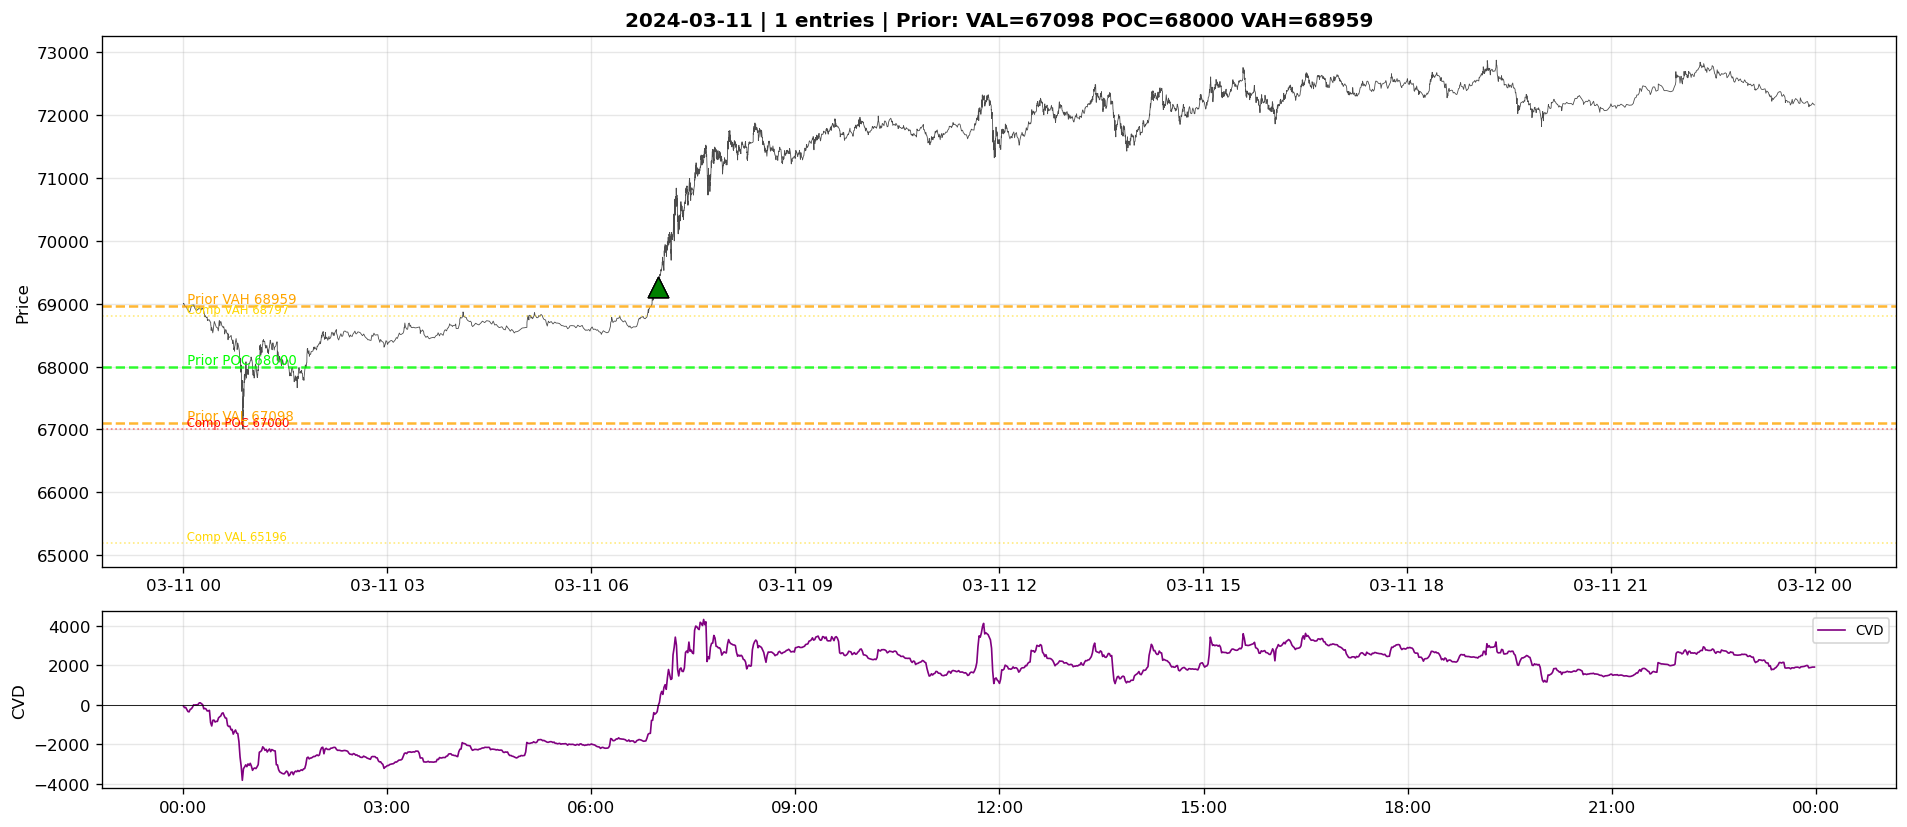

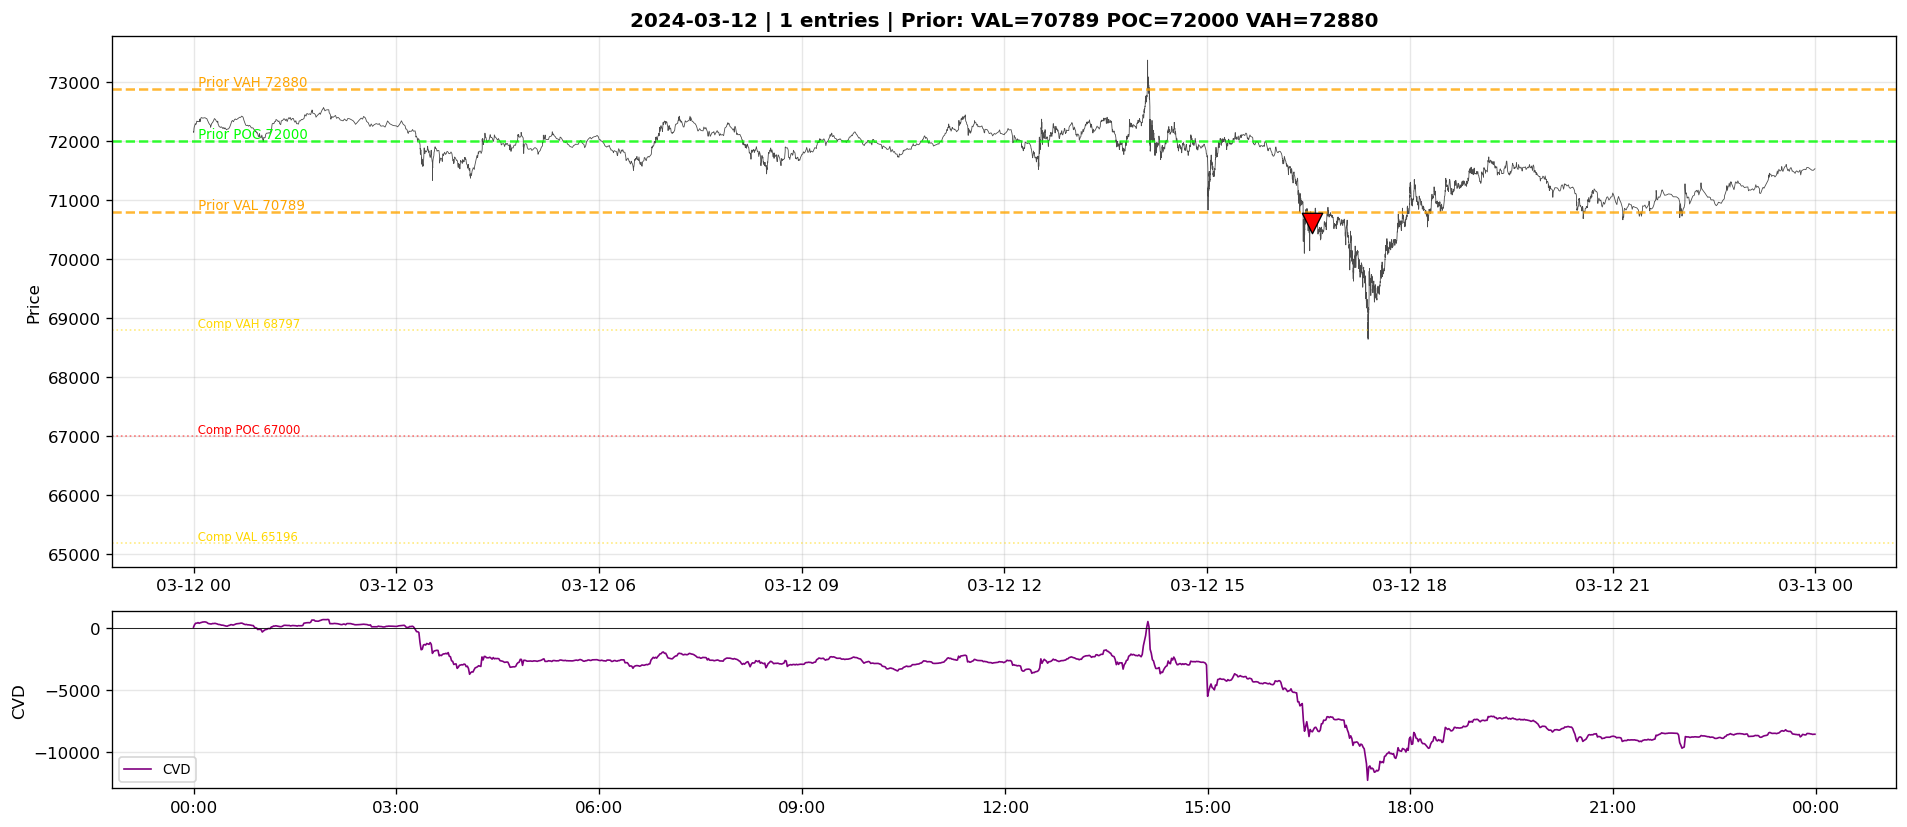

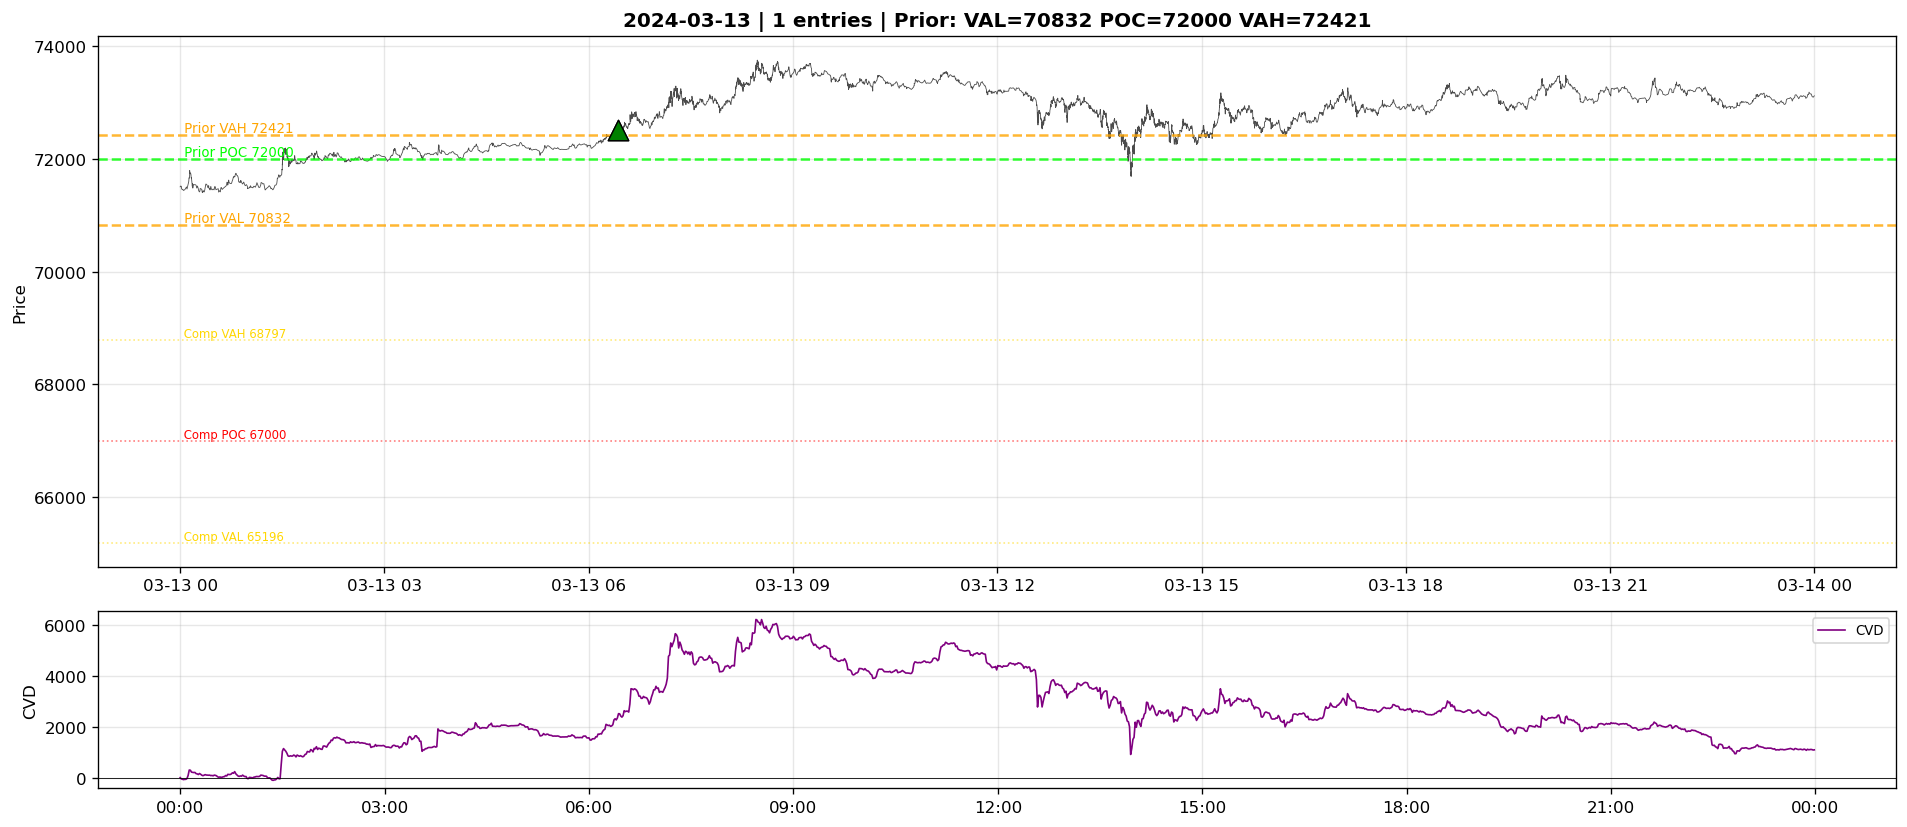

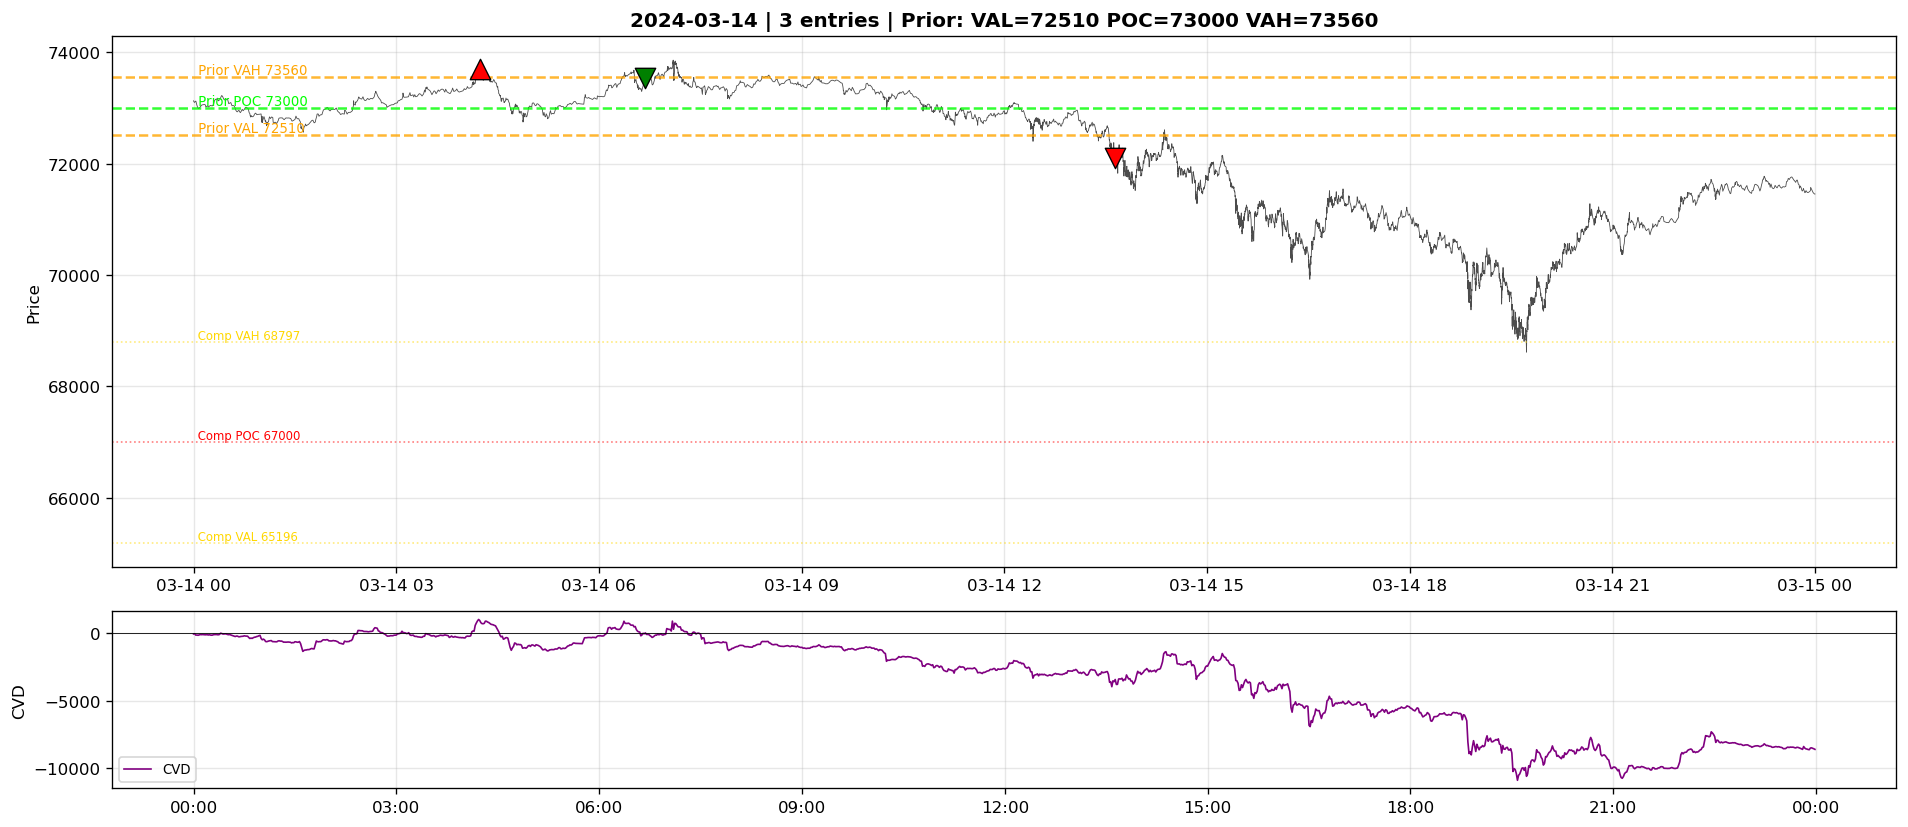

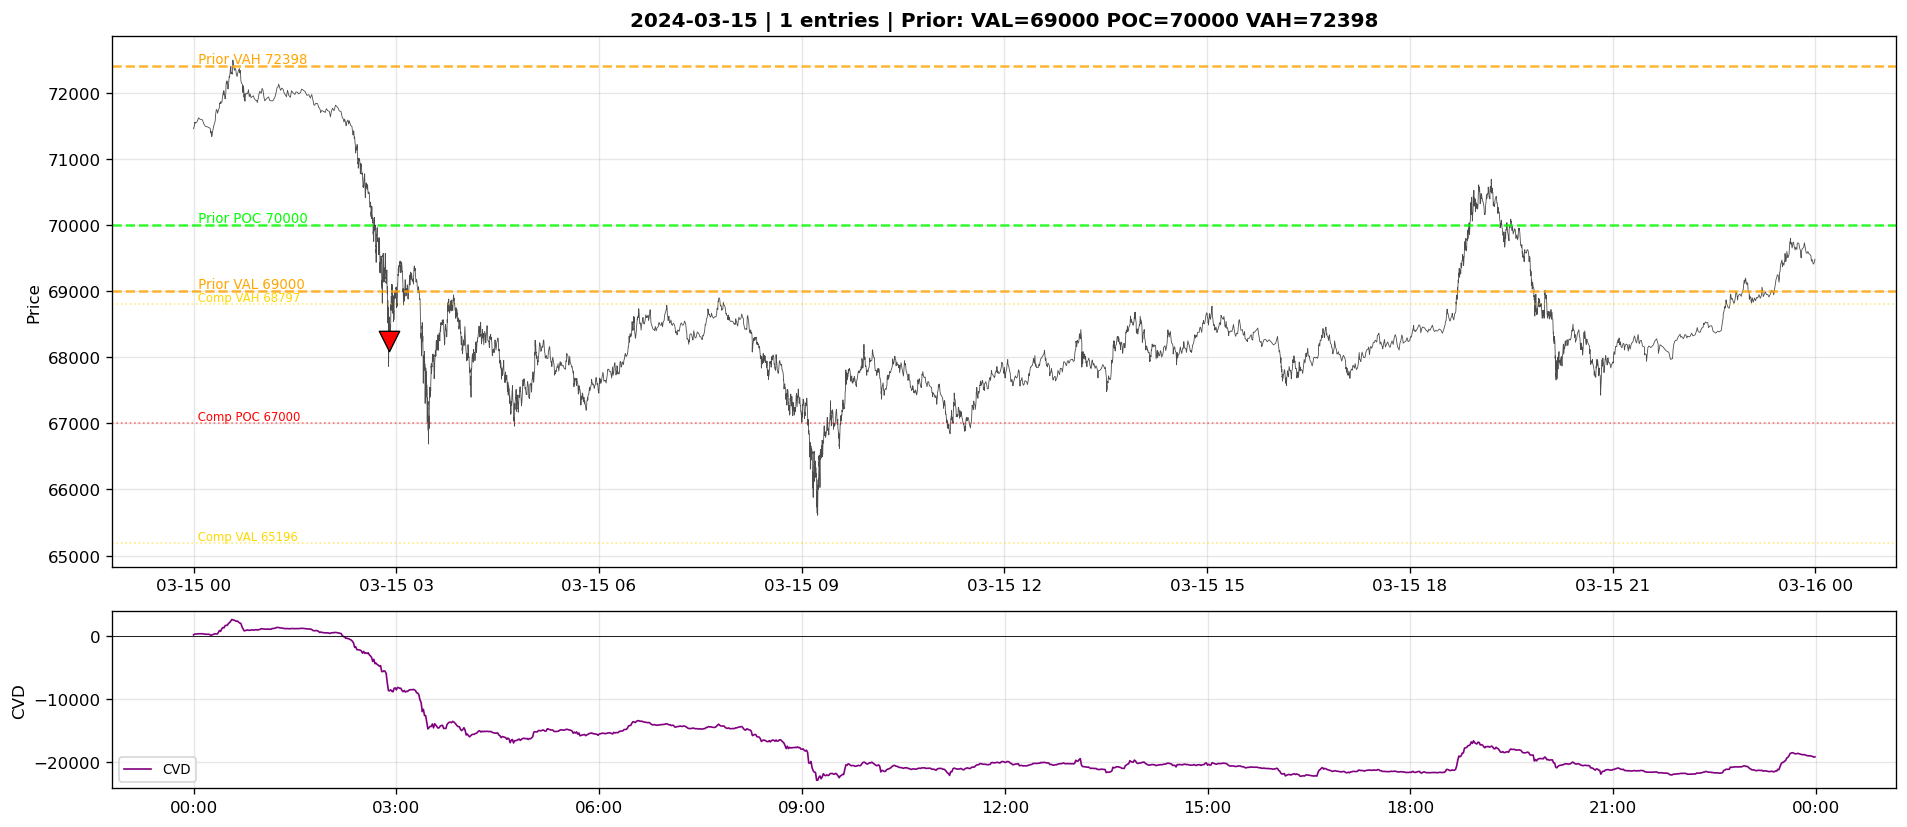

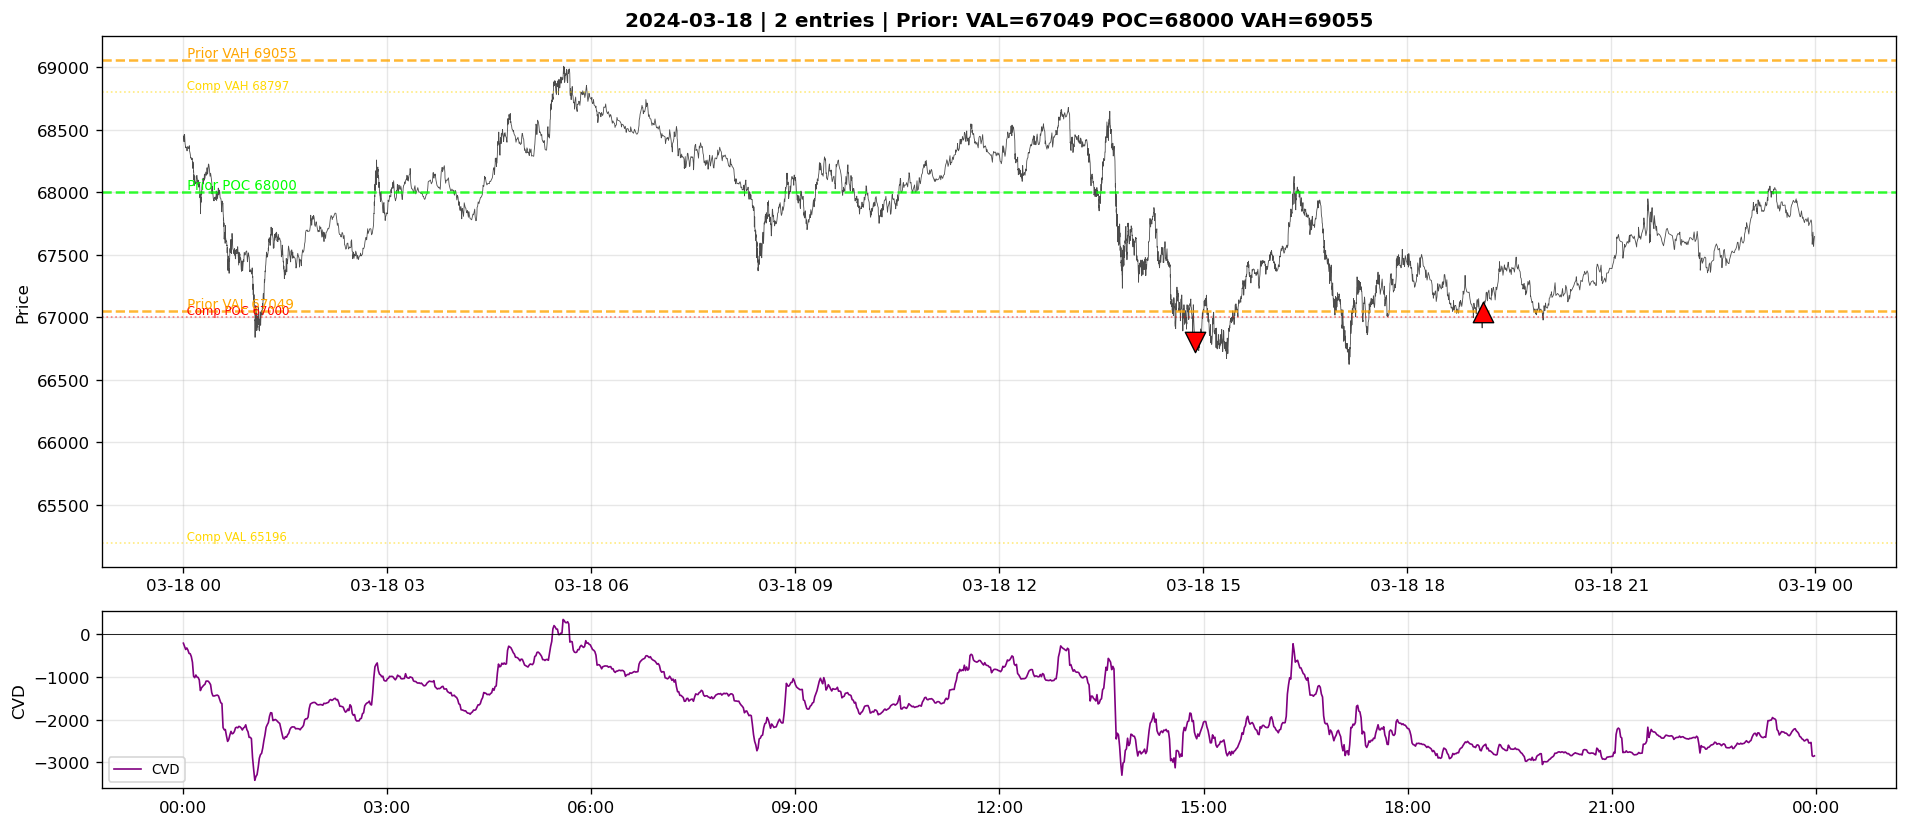

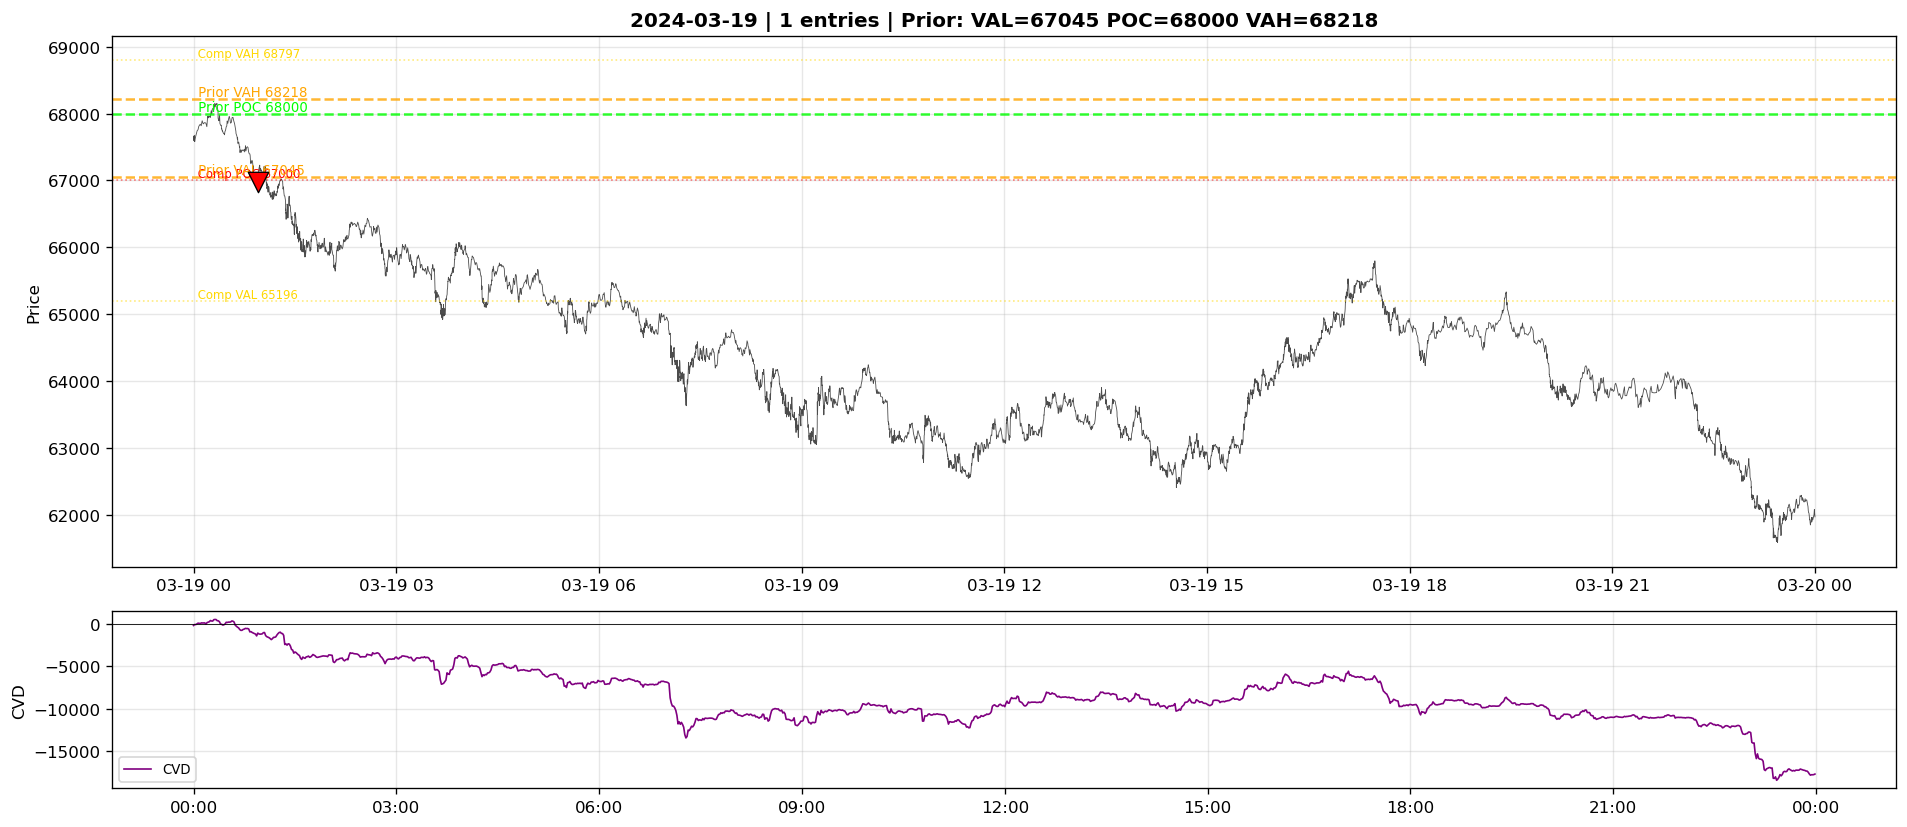

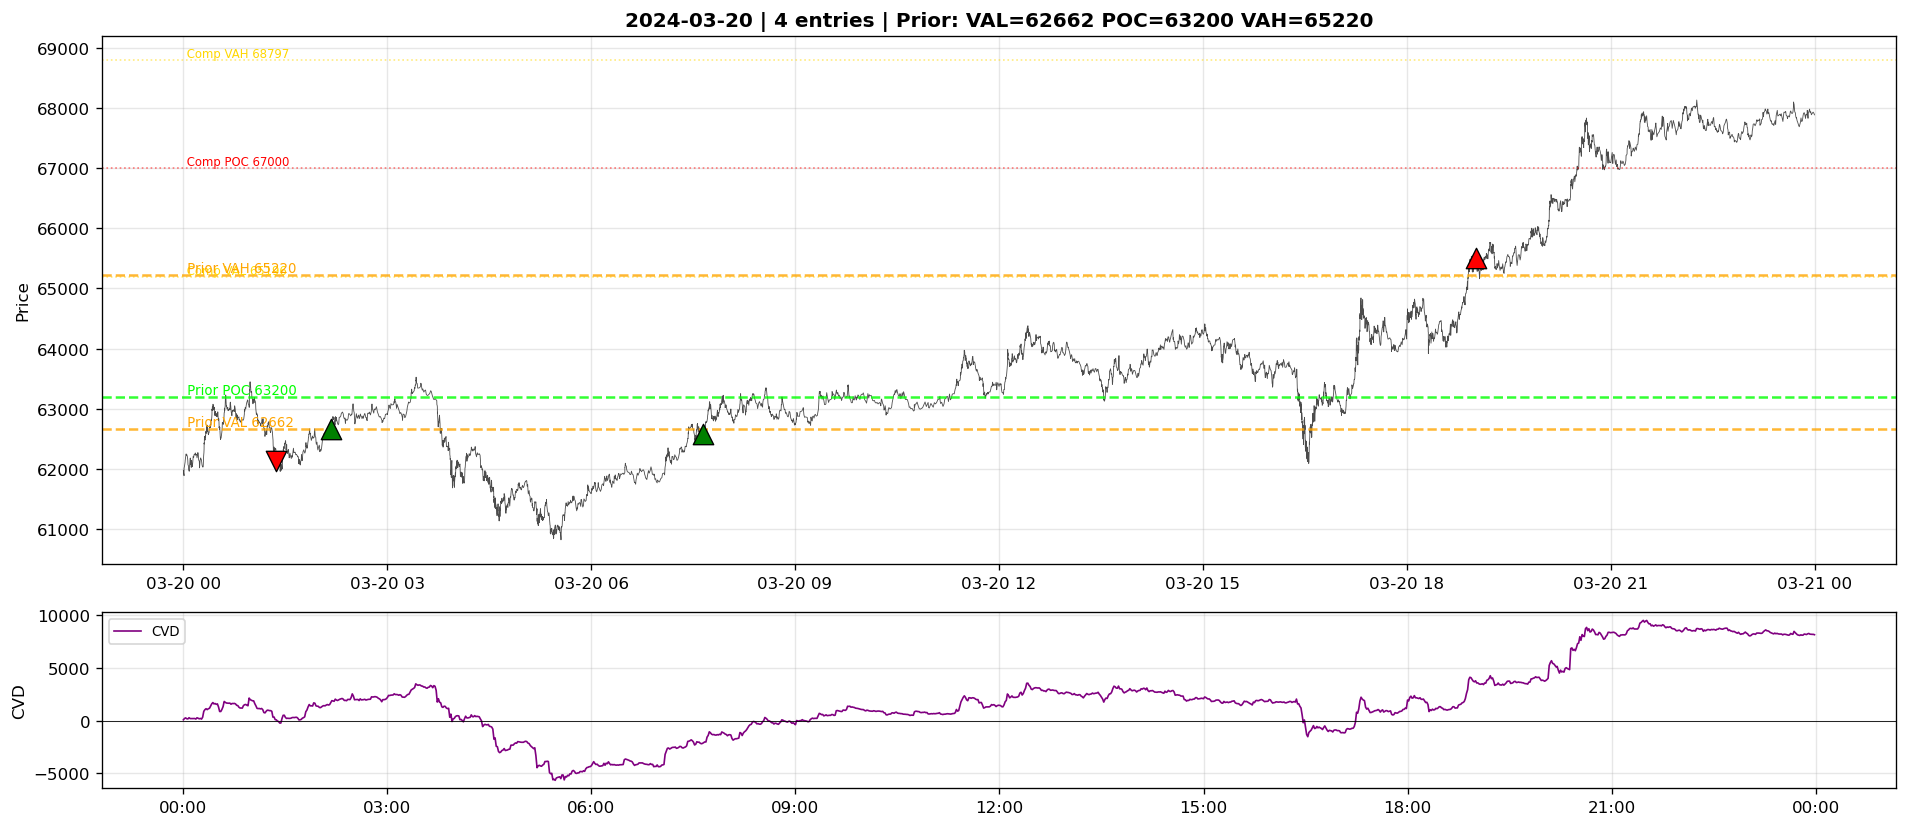

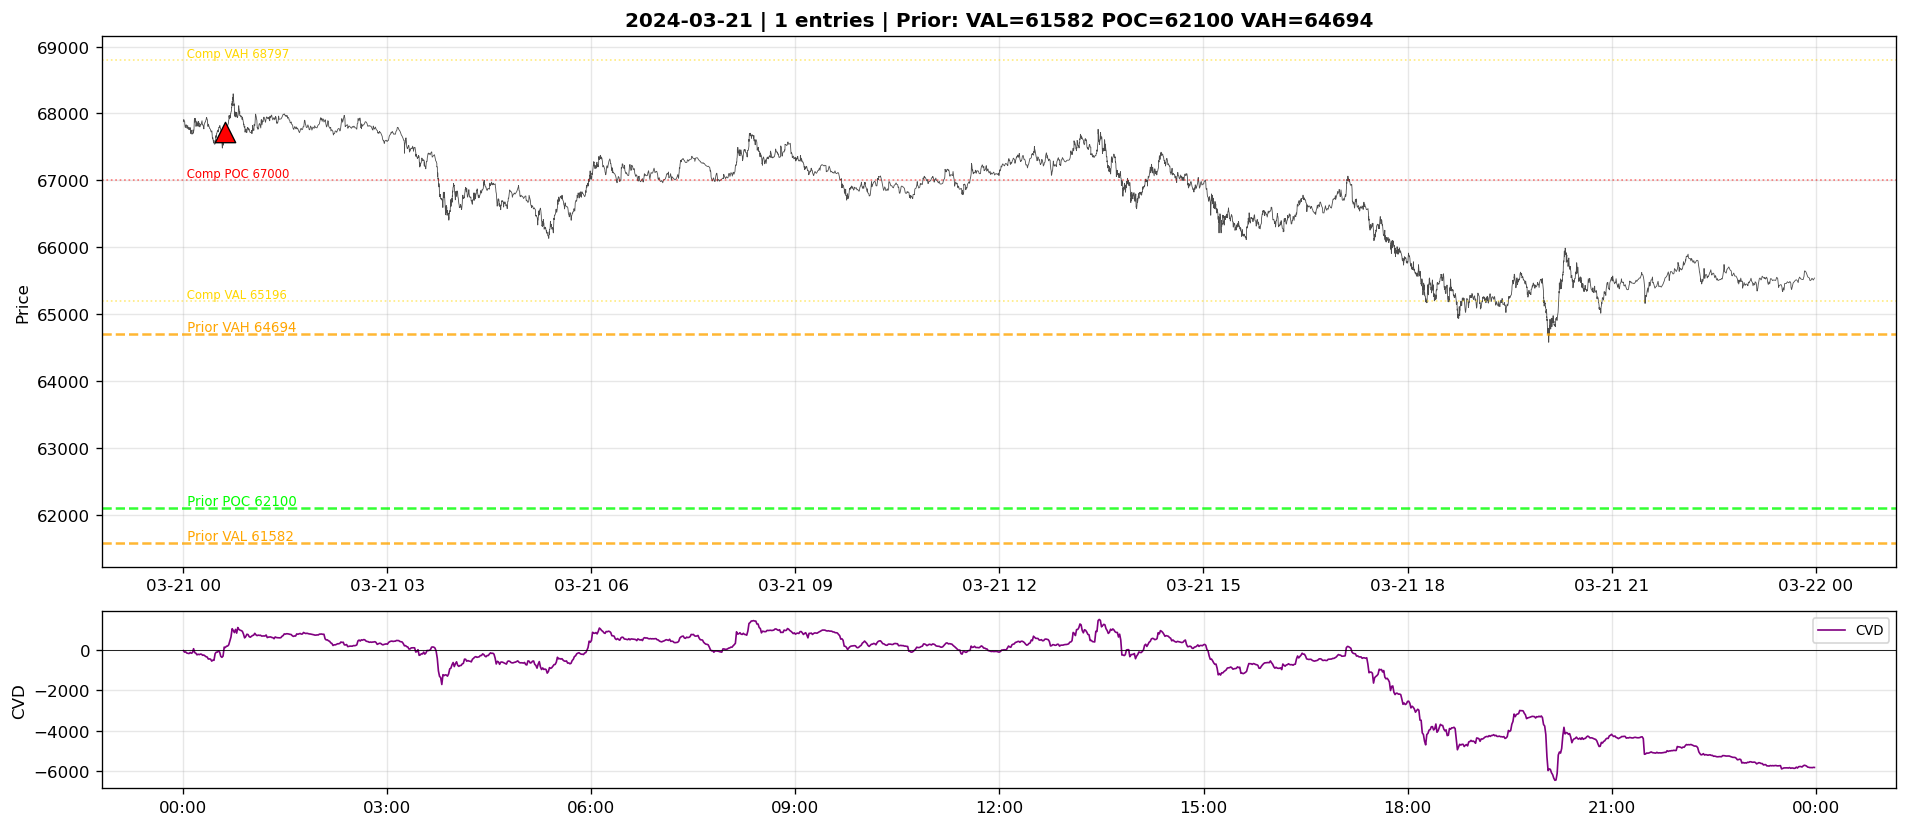

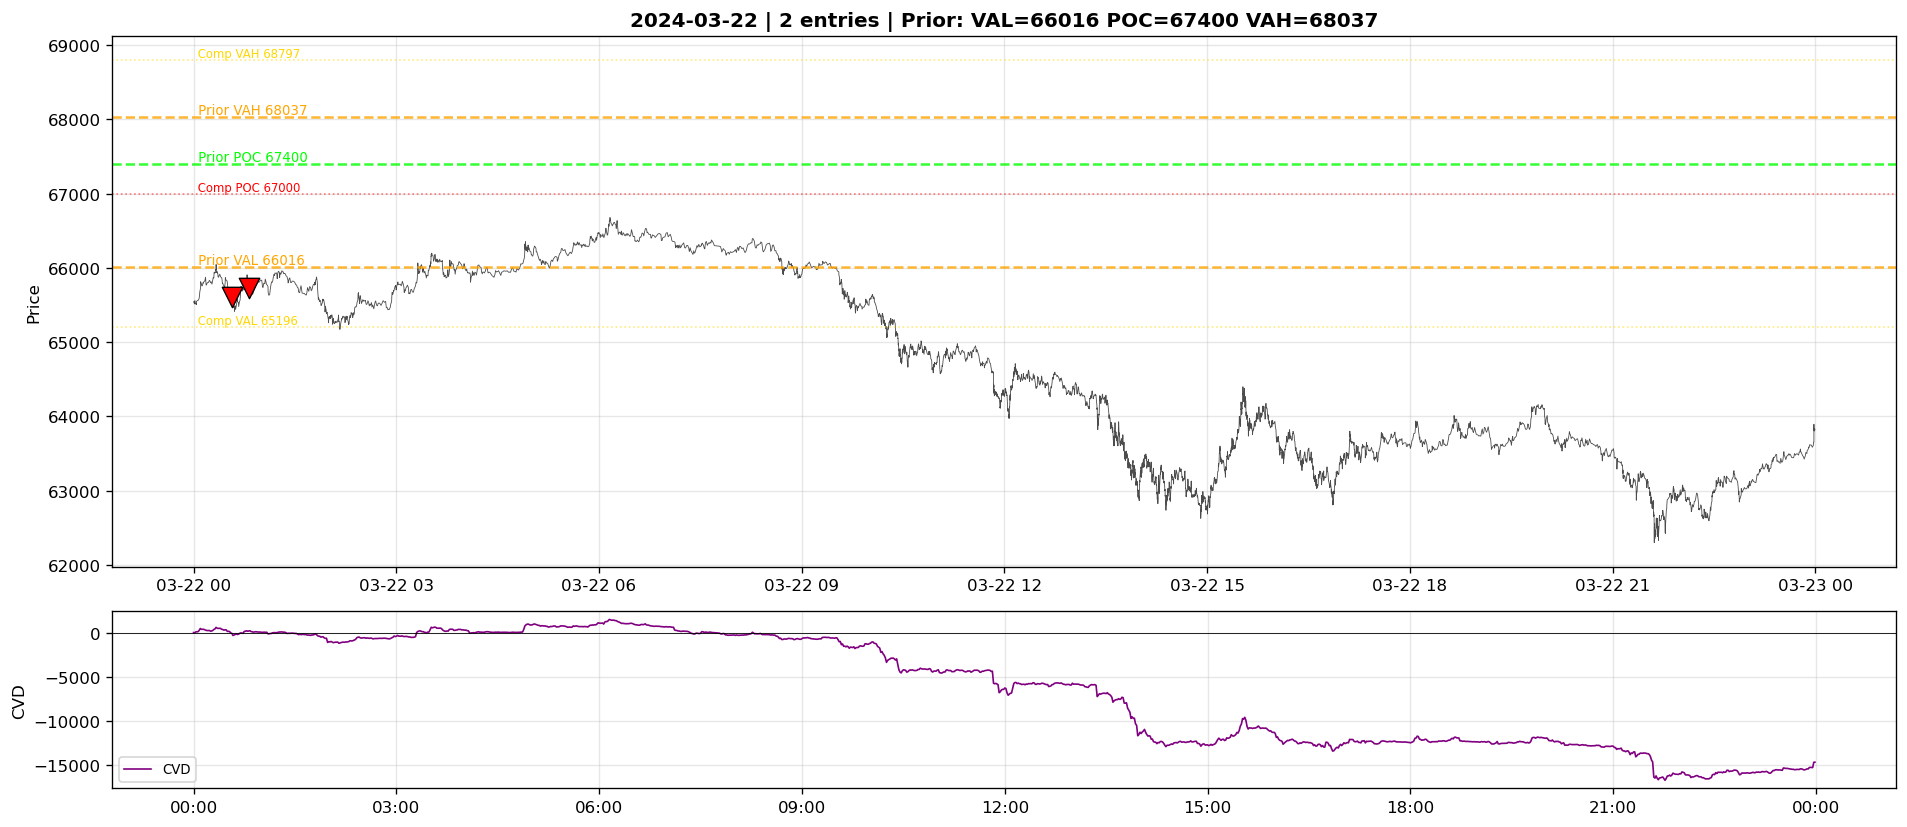

In [9]:
# === Charts ===
for d in TEST_DAYS:
    r=results[d]
    tr=r['trades']
    ev=r['events']
    pp=r['prior_prof']
    
    times, prices = [], []
    for e in ev:
        if e['t']=='tr':
            times.append(pd.Timestamp(e['ts'],unit='ms'))
            prices.append(e['p'])
    if not times: continue
    step=max(1,len(times)//5000)
    
    fig,axes=plt.subplots(2,1,figsize=(16,7),gridspec_kw={'height_ratios':[3,1]})
    ax1,ax2=axes
    
    ax1.plot(times[::step],prices[::step],'k-',lw=0.5,alpha=0.7)
    
    for label,px,color in [
        (f'Comp VAL {COMP_VAL:.0f}',COMP_VAL,'gold'),
        (f'Comp POC {COMP_POC:.0f}',COMP_POC,'red'),
        (f'Comp VAH {COMP_VAH:.0f}',COMP_VAH,'gold'),
    ]:
        ax1.axhline(px,color=color,lw=1,ls=':',alpha=0.5)
        ax1.text(times[0],px,f' {label}',fontsize=7,color=color,va='bottom')
    
    for label,px,color in [
        (f'Prior VAL {pp["val"]:.0f}',pp['val'],'orange'),
        (f'Prior POC {pp["poc"]:.0f}',pp['poc'],'lime'),
        (f'Prior VAH {pp["vah"]:.0f}',pp['vah'],'orange'),
    ]:
        ax1.axhline(px,color=color,lw=1.5,ls='--',alpha=0.8)
        ax1.text(times[0],px,f' {label}',fontsize=8,color=color,va='bottom')
    
    if len(tr)>0:
        for _,r2 in tr.iterrows():
            t_entry=pd.Timestamp(r2['ts_entry'],unit='ms') if r2['ts_entry'] else times[len(times)//2]
            col='green' if r2['pnl_pct']>0 else 'red'
            mk='^' if r2['side']=='LONG' else 'v'
            ax1.scatter(t_entry,r2['entry'],marker=mk,color=col,s=150,
                       zorder=5,edgecolors='black',linewidth=0.8)
    
    ax1.set_title(f'{d} | {tr["entry"].nunique() if len(tr)>0 else 0} entries | '
                  f'Prior: VAL={pp["val"]:.0f} POC={pp["poc"]:.0f} VAH={pp["vah"]:.0f}',
                  fontweight='bold')
    ax1.set_ylabel('Price'); ax1.grid(alpha=0.3)
    
    mdeltas={}
    for e in ev:
        if e['t']=='tr':
            m=e['ts']//60_000
            mdeltas[m]=mdeltas.get(m,0)+(-e['q'] if e['b'] else e['q'])
    if mdeltas:
        mt=sorted(mdeltas.keys()); mv=[mdeltas[m] for m in mt]
        ml=[pd.Timestamp(m*60_000,unit='ms') for m in mt]
        cvd_line=np.cumsum(mv)
        ax2.plot(ml,cvd_line,color='purple',lw=1,label='CVD')
        ax2.axhline(0,color='black',lw=0.5)
        ax2.set_ylabel('CVD'); ax2.grid(alpha=0.3); ax2.legend(fontsize=8)
    
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout(); plt.show()

---
## v9 Changes

- **Fixed charts**: removed `matplotlib.use('Agg')` so plots render inline
- **Extended test window**: 10 trading days (Mar 11-22) instead of 5
- Same v8 strategy logic (value boundary entries, CVD regime, multi-target exits)